#### Noisy QSVM (SVC Precomputed Kernel) - Spambase

In [1]:
%pip install qiskit qiskit-machine-learning qiskit-aer seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 47.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 94.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 69.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 65.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 61.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 74.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 59.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 100.6 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [2]:
import qiskit, qiskit_aer, qiskit_machine_learning
print("Qiskit:", qiskit.__version__)
print("Aer:", qiskit_aer.__version__)
print("QML:", qiskit_machine_learning.__version__)

KeyboardInterrupt: 

In [ ]:
# To ensure reproducibility of results
from qiskit_machine_learning.utils import algorithm_globals
algorithm_globals.random_seed = 12345

In [ ]:
# --- Import Libraries ---
import pandas as pd
import numpy as np
import time
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif, VarianceThreshold
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, recall_score, balanced_accuracy_score

In [ ]:
# --- Qiskit Imports ---
from qiskit.circuit.library import ZZFeatureMap
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error, ReadoutError
from qiskit.primitives import StatevectorSampler as Sampler
from qiskit_aer.primitives import SamplerV2 as AerSampler
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_machine_learning.state_fidelities import ComputeUncompute
from qiskit_machine_learning.kernels import FidelityQuantumKernel
from qiskit_machine_learning.algorithms import QSVC, PegasosQSVC

Load Dataset

In [ ]:
# --- Import Spambase Column Names ---
spambase_columns = [
    "word_freq_make",
    "word_freq_address",
    "word_freq_all",
    "word_freq_3d",
    "word_freq_our",
    "word_freq_over",
    "word_freq_remove",
    "word_freq_internet",
    "word_freq_order",
    "word_freq_mail",
    "word_freq_receive",
    "word_freq_will",
    "word_freq_people",
    "word_freq_report",
    "word_freq_addresses",
    "word_freq_free",
    "word_freq_business",
    "word_freq_email",
    "word_freq_you",
    "word_freq_credit",
    "word_freq_your",
    "word_freq_font",
    "word_freq_000",
    "word_freq_money",
    "word_freq_hp",
    "word_freq_hpl",
    "word_freq_george",
    "word_freq_650",
    "word_freq_lab",
    "word_freq_labs",
    "word_freq_telnet",
    "word_freq_857",
    "word_freq_data",
    "word_freq_415",
    "word_freq_85",
    "word_freq_technology",
    "word_freq_1999",
    "word_freq_parts",
    "word_freq_pm",
    "word_freq_direct",
    "word_freq_cs",
    "word_freq_meeting",
    "word_freq_original",
    "word_freq_project",
    "word_freq_re",
    "word_freq_edu",
    "word_freq_table",
    "word_freq_conference",
    "char_freq_;",
    "char_freq_(",
    "char_freq_[",
    "char_freq_!",
    "char_freq_$",
    "char_freq_#",
    "capital_run_length_average",
    "capital_run_length_longest",
    "capital_run_length_total",
    "label"
]

# --- 1. Load the Spambase Dataset (LOCAL PATH) ---
# file_path = '/kaggle/input/spambase/spambase.data'
# file_path = r'C:\Users\User\Documents\MyProjects\FYP_ResearchProject\data\spambase\spambase.data'
file_path = "/home/azureuser/cloudfiles/code/data/spambase/spambase.data"
df = pd.read_csv(file_path, header=None, names=spambase_columns)
df.drop_duplicates(inplace=True)

print(f"Dataset loaded: {df.shape[0]} samples, {df.shape[1]} features")

Dataset loaded: 4210 samples, 58 features


Noise Model Factory Function

In [ ]:
def get_noise_model(level='standard'):
    """
    Returns a noise model, backend, and pass manager for the given noise level.
    
    Noise Levels:
    - 'low': 0.01% 1q, 0.1% 2q, 0.2% readout
    - 'standard': 0.1% 1q, 1.0% 2q, 2.0% readout (realistic NISQ device)
    - 'high': 0.5% 1q, 5.0% 2q, 10.0% readout
    """
    noise_params = {
        'low': {'p_1q': 0.0001, 'p_2q': 0.001, 'p_ro': 0.002},
        'standard': {'p_1q': 0.001, 'p_2q': 0.01, 'p_ro': 0.02},
        'high': {'p_1q': 0.005, 'p_2q': 0.05, 'p_ro': 0.10},
    }
    
    params = noise_params.get(level, noise_params['standard'])
    
    noise_model = NoiseModel()
    noise_model.add_all_qubit_quantum_error(depolarizing_error(params['p_1q'], 1), ['u1', 'u2', 'u3'])
    noise_model.add_all_qubit_quantum_error(depolarizing_error(params['p_2q'], 2), ['cx'])
    readout_error = ReadoutError([[1 - params['p_ro'], params['p_ro']], [params['p_ro'], 1 - params['p_ro']]])
    noise_model.add_all_qubit_readout_error(readout_error)
    
    backend = AerSimulator(noise_model=noise_model, seed_simulator=12345, max_parallel_threads=16, max_parallel_experiments=0)
    pm = generate_preset_pass_manager(optimization_level=1, backend=backend)
    
    return noise_model, backend, pm, params
    
print("Noise model factory function ready!")
print("Available levels: 'low', 'standard', 'high'")

Noise model factory function ready!
Available levels: 'low', 'standard', 'high'


Experiment Configurations

In [ ]:
# ==========================================
# EXPERIMENT CONFIGURATIONS
# ==========================================

experiments = [
    # --- EXP 1: Sample Size Effect (Generalization) ---
    {'id': 'Exp1_100samp',  'samples': 100, 'k_features': 8, 'shots': 1024, 'reps': 1, 'entanglement': 'linear', 'noise_level': 'standard'},
    {'id': 'Exp1_200samp',  'samples': 200, 'k_features': 8, 'shots': 1024, 'reps': 1, 'entanglement': 'linear', 'noise_level': 'standard'},
    {'id': 'Exp1_300samp',  'samples': 300, 'k_features': 8, 'shots': 1024, 'reps': 1, 'entanglement': 'linear', 'noise_level': 'standard'},
    {'id': 'Exp1_500samp',  'samples': 500, 'k_features': 8, 'shots': 1024, 'reps': 1, 'entanglement': 'linear', 'noise_level': 'standard'},

    # --- EXP 2: Dimensionality Effect (Quantum Complexity) ---
    {'id': 'Exp2_2feat', 'samples': 300, 'k_features': 2, 'shots': 1024, 'reps': 1, 'entanglement': 'linear', 'noise_level': 'standard'},
    {'id': 'Exp2_4feat', 'samples': 300, 'k_features': 4, 'shots': 1024, 'reps': 1, 'entanglement': 'linear', 'noise_level': 'standard'},
    {'id': 'Exp2_6feat', 'samples': 300, 'k_features': 6, 'shots': 1024, 'reps': 1, 'entanglement': 'linear', 'noise_level': 'standard'},
    {'id': 'Exp2_8feat', 'samples': 300, 'k_features': 8, 'shots': 1024, 'reps': 1, 'entanglement': 'linear', 'noise_level': 'standard'},
    {'id': 'Exp2_10feat', 'samples': 300, 'k_features': 10, 'shots': 1024, 'reps': 1, 'entanglement': 'linear', 'noise_level': 'standard'},
    {'id': 'Exp2_12feat', 'samples': 300, 'k_features': 12, 'shots': 1024, 'reps': 1, 'entanglement': 'linear', 'noise_level': 'standard'},

    # --- EXP 3: Shot Noise Effect (Measurement Precision) ---
    {'id': 'Exp3_128shots', 'samples': 300, 'k_features': 8, 'shots': 128, 'reps': 1, 'entanglement': 'linear', 'noise_level': 'standard'},
    {'id': 'Exp3_512shots', 'samples': 300, 'k_features': 8, 'shots': 512, 'reps': 1, 'entanglement': 'linear', 'noise_level': 'standard'},
    {'id': 'Exp3_1024shots', 'samples': 300, 'k_features': 8, 'shots': 1024, 'reps': 1, 'entanglement': 'linear', 'noise_level': 'standard'},

    # --- EXP 4: Reps Effect (NEW: Circuit Complexity) ---
    {'id': 'Exp4_Reps1', 'samples': 300, 'k_features': 8, 'shots': 1024, 'reps': 1, 'entanglement': 'linear', 'noise_level': 'standard'},
    {'id': 'Exp4_Reps2', 'samples': 300, 'k_features': 8, 'shots': 1024, 'reps': 2, 'entanglement': 'linear', 'noise_level': 'standard'},
    {'id': 'Exp4_Reps3', 'samples': 300, 'k_features': 8, 'shots': 1024, 'reps': 3, 'entanglement': 'linear', 'noise_level': 'standard'},

    # --- EXP 5: Entanglement Ablation (NEW) ---
    {'id': 'Exp5_Linear', 'samples': 300, 'k_features': 8, 'shots': 1024, 'reps': 1, 'entanglement': 'linear', 'noise_level': 'standard'},
    {'id': 'Exp5_Circular', 'samples': 300, 'k_features': 8, 'shots': 1024, 'reps': 1, 'entanglement': 'circular', 'noise_level': 'standard'},
    {'id': 'Exp5_Full', 'samples': 300, 'k_features': 8, 'shots': 1024, 'reps': 1, 'entanglement': 'full', 'noise_level': 'standard'},

    # --- EXP 6: Noise Ablation (NEW - Noise-specific experiments) ---
    {'id': 'Exp6_LowNoise', 'samples': 300, 'k_features': 8, 'shots': 1024, 'reps': 1, 'entanglement': 'linear', 'noise_level': 'low'},
    {'id': 'Exp6_StdNoise', 'samples': 300, 'k_features': 8, 'shots': 1024, 'reps': 1, 'entanglement': 'linear', 'noise_level': 'standard'},
    {'id': 'Exp6_HighNoise', 'samples': 300, 'k_features': 8, 'shots': 1024, 'reps': 1, 'entanglement': 'linear', 'noise_level': 'high'},
]

print(f"Total experiments configured: {len(experiments)}")
print("Running might take hours or even several days")


Total experiments configured: 22
Running might take hours or even several days


Main Experiment

In [ ]:
# ===================================================================
# MAIN EXPERIMENT LOOP (RESUMABLE VERSION)
# ===================================================================
import os

all_results = []

for exp_num, config in enumerate(experiments, 1):
    print("\n" + "="*80)
    print(f"EXPERIMENT {exp_num}/{len(experiments)}: {config['id']}")
    print("="*80)

    # --- CHECK IF ALREADY DONE ---
    train_file = f'kernel_train_{config["id"]}.npy'
    test_file = f'kernel_test_{config["id"]}.npy'

    if os.path.exists(train_file) and os.path.exists(test_file):
        print(f"Found existing kernel files for {config['id']}. SKIPPING calculation to save time.")
        continue 
    # -----------------------------

    print(f" Samples: {config['samples']}")
    print(f" K Features: {config['k_features']}")
    print(f" Shots: {config['shots']}")
    print(f" Reps: {config['reps']}")
    print(f" Entanglement: {config['entanglement']}")
    print(f" Noise Level: {config.get('noise_level', 'standard')}")
    print("="*80)

    # ===================================================================
    # 0. GET NOISE MODEL (NEW FOR NOISY VERSION)
    # ===================================================================
    
    noise_level = config.get('noise_level', 'standard')
    noise_model, noisy_backend, pm, noise_params = get_noise_model(noise_level)
    print(f"Noise Model: 1q={noise_params['p_1q']*100:.2f}%, 2q={noise_params['p_2q']*100:.2f}%, readout={noise_params['p_ro']*100:.2f}%")

    # ===================================================================
    # 1. DATA PREPARATION
    # ===================================================================

    X = df.drop('label', axis=1)
    y = df['label']

    # --- SUBSET SELECTION (Follow ideal structure) ---
    X_subset, _, y_subset, _ = train_test_split(
        X, y,
        train_size=config['samples'],
        stratify=y,
        random_state=42
    )

    X_train, X_test, y_train, y_test = train_test_split(
        X_subset, y_subset,
        test_size=0.30,
        random_state=42,
        stratify=y_subset
    )

    print(f"\nDataset created: {X_train.shape[0]} train, {X_test.shape[0]} test")

    # ===================================================================
    # 2. SCALING
    # ===================================================================

    # 2. VARIANCE FILTERING & SCALING (Prevents "Invalid Value" errors)
    selector_variance = VarianceThreshold(threshold=0)
    X_train_filtered = selector_variance.fit_transform(X_train)
    X_test_filtered = selector_variance.transform(X_test)
    remaining_cols = X_train.columns[selector_variance.get_support()]

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_filtered)
    X_test_scaled = scaler.transform(X_test_filtered)
    X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=remaining_cols)
    X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=remaining_cols)

    print("Data scaled successfully")

    # ===================================================================
    # 3. CORRELATION-BASED FEATURE DROPPING
    # ===================================================================

    THRESH = 0.9
    corr_matrix_train = X_train_scaled_df.corr().abs()
    upper_triangle = corr_matrix_train.where(
        np.triu(np.ones(corr_matrix_train.shape), k=1).astype(bool)
    )

    columns_to_drop = set()
    for column in upper_triangle.columns:
        high_corr_partners = upper_triangle.index[upper_triangle[column] > THRESH].tolist()
        if high_corr_partners:
            for partner in high_corr_partners:
                corr_main_vs_target = y_train.corr(X_train_scaled_df[column])
                corr_partner_vs_target = y_train.corr(X_train_scaled_df[partner])

                if abs(corr_main_vs_target) < abs(corr_partner_vs_target):
                    columns_to_drop.add(column)
                else:
                    columns_to_drop.add(partner)

    to_drop_final = sorted(list(columns_to_drop))
    X_train_selected = X_train_scaled_df.drop(columns=to_drop_final)
    X_test_selected = X_test_scaled_df.drop(columns=to_drop_final)

    print(f"Dropped {len(to_drop_final)} highly correlated features")

    # ===================================================================
    # 4. SELECTKBEST
    # ===================================================================

    k_features = config['k_features']
    selector = SelectKBest(score_func=f_classif, k=k_features)
    X_train_kbest = selector.fit_transform(X_train_selected, y_train)
    X_test_kbest = selector.transform(X_test_selected)
    

    selected_features = X_train_selected.columns[selector.get_support()].tolist()
    print(f"SelectKBest: Selected {k_features} features:")
    for i, feat in enumerate(selected_features, 1):
        print(f" {i}. {feat}")

    # ===================================================================
    # 5. QUANTUM KERNEL SETUP (NOISY VERSION)
    # ===================================================================

    # Use NOISY sampler instead of ideal sampler
    sampler = AerSampler.from_backend(
        backend=noisy_backend,
        default_shots=config['shots']
    )

    fm = ZZFeatureMap(
        feature_dimension=k_features,
        reps=config['reps'],
        entanglement=config['entanglement']
    )

    
    fidelity = ComputeUncompute(sampler=sampler, pass_manager=pm)
    qkernel = FidelityQuantumKernel(fidelity=fidelity, feature_map=fm)

    print(f"Quantum kernel configured (ZZFeatureMap, reps={config['reps']}, entanglement={config['entanglement']})")

    # ===================================================================
    # 6. COMPUTE KERNEL MATRICES
    # ===================================================================

    print("\nComputing kernel matrices...")
    start_kernel = time.time()

    matrix_train = qkernel.evaluate(x_vec=X_train_kbest)
    matrix_test = qkernel.evaluate(x_vec=X_test_kbest, y_vec=X_train_kbest)

    kernel_time = time.time() - start_kernel
    print(f"Kernel computation: {kernel_time:.2f}s")

    # ===================================================================
    # 7. GRID SEARCH
    # ===================================================================

    print("\nGrid searching for optimal C...")
    param_grid = {'C': [0.001, 0.01, 0.1, 1, 10, 100]}
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

    grid_search = GridSearchCV(
        SVC(kernel='precomputed', class_weight='balanced'),
        param_grid,
        cv=cv,
        scoring='accuracy',
        verbose=0,
        n_jobs=-1
    )

    start_train = time.time()
    grid_search.fit(matrix_train, y_train)
    train_time = time.time() - start_train

    best_model = grid_search.best_estimator_
    best_c = grid_search.best_params_['C']
    cv_score = grid_search.best_score_

    print(f" → Best C: {best_c}")
    print(f" → CV Score: {cv_score:.4f}")
    print(f" → Training time: {train_time:.2f}s")

    # ===================================================================
    # 8. EVALUATION
    # ===================================================================

    y_train_pred = best_model.predict(matrix_train)
    y_test_pred = best_model.predict(matrix_test)

    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    test_balanced_acc = balanced_accuracy_score(y_test, y_test_pred)
    spam_recall = recall_score(y_test, y_test_pred, pos_label=1)
    gen_gap = abs(train_acc - test_acc)

    print(f" → Train Accuracy: {train_acc:.4f}")
    print(f" → Test Accuracy: {test_acc:.4f}")
    print(f" → Test Balanced Accuracy: {test_balanced_acc:.4f}")
    print(f" → Spam Recall: {spam_recall:.4f}")
    print(f" → Generalization Gap: {gen_gap:.4f}")

    # ===================================================================
    # 9. STORE RESULTS
    # ===================================================================

    all_results.append({
        'experiment_id': config['id'],
        'exp_number': exp_num,
        'samples': config['samples'],
        'k_features': k_features,
        'shots': config['shots'],
        'reps': config['reps'],
        'entanglement': config['entanglement'],
        'noise_level': noise_level,
        'selected_features': selected_features,
        'best_c': best_c,
        'cv_score': cv_score,
        'train_acc': train_acc,
        'test_acc': test_acc,
        'test_balanced_acc': test_balanced_acc,
        'spam_recall': spam_recall,
        'gen_gap': gen_gap,
        'kernel_time': kernel_time,
        'train_time': train_time
    })

    # Print classification report
    print("\n" + "Classification Report:")
    print(classification_report(y_test, y_test_pred, zero_division=0))

    # Save kernel matrices
    np.save(f'kernel_train_{config["id"]}.npy', matrix_train)
    np.save(f'kernel_test_{config["id"]}.npy', matrix_test)
    print(f"Saved kernel matrices: kernel_train_{config['id']}.npy, kernel_test_{config['id']}.npy")

print("\n" + "="*80)
print("ALL EXPERIMENTS COMPLETE!")
print("="*80)



EXPERIMENT 1/22: Exp1_100samp
Found existing kernel files for Exp1_100samp. SKIPPING calculation to save time.

EXPERIMENT 2/22: Exp1_200samp
Found existing kernel files for Exp1_200samp. SKIPPING calculation to save time.

EXPERIMENT 3/22: Exp1_300samp
Found existing kernel files for Exp1_300samp. SKIPPING calculation to save time.

EXPERIMENT 4/22: Exp1_500samp
Found existing kernel files for Exp1_500samp. SKIPPING calculation to save time.

EXPERIMENT 5/22: Exp2_2feat
Found existing kernel files for Exp2_2feat. SKIPPING calculation to save time.

EXPERIMENT 6/22: Exp2_4feat
Found existing kernel files for Exp2_4feat. SKIPPING calculation to save time.

EXPERIMENT 7/22: Exp2_6feat
Found existing kernel files for Exp2_6feat. SKIPPING calculation to save time.

EXPERIMENT 8/22: Exp2_8feat
Found existing kernel files for Exp2_8feat. SKIPPING calculation to save time.

EXPERIMENT 9/22: Exp2_10feat
Found existing kernel files for Exp2_10feat. SKIPPING calculation to save time.

EXPERIMEN

/anaconda/envs/jupyter_env/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/anaconda/envs/jupyter_env/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/tmp/ipykernel_7832/437083477.py:134: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  fm = ZZFeatureMap(


Kernel computation: 12295.77s

Grid searching for optimal C...
 → Best C: 10
 → CV Score: 0.7857
 → Training time: 2.37s
 → Train Accuracy: 1.0000
 → Test Accuracy: 0.8222
 → Test Balanced Accuracy: 0.8380
 → Spam Recall: 0.9167
 → Generalization Gap: 0.1778

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.76      0.84        54
           1       0.72      0.92      0.80        36

    accuracy                           0.82        90
   macro avg       0.82      0.84      0.82        90
weighted avg       0.85      0.82      0.82        90

Saved kernel matrices: kernel_train_Exp2_12feat.npy, kernel_test_Exp2_12feat.npy

EXPERIMENT 11/22: Exp3_128shots
 Samples: 300
 K Features: 8
 Shots: 128
 Reps: 1
 Entanglement: linear
 Noise Level: standard
Noise Model: 1q=0.10%, 2q=1.00%, readout=2.00%

Dataset created: 210 train, 90 test
Data scaled successfully
Dropped 1 highly correlated features
SelectKBest: Selected 8 features:
 

/anaconda/envs/jupyter_env/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/anaconda/envs/jupyter_env/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/tmp/ipykernel_7832/437083477.py:134: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  fm = ZZFeatureMap(


Kernel computation: 676.45s

Grid searching for optimal C...
 → Best C: 1
 → CV Score: 0.7571
 → Training time: 2.28s
 → Train Accuracy: 0.9762
 → Test Accuracy: 0.8333
 → Test Balanced Accuracy: 0.8472
 → Spam Recall: 0.9167
 → Generalization Gap: 0.1429

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.78      0.85        54
           1       0.73      0.92      0.81        36

    accuracy                           0.83        90
   macro avg       0.83      0.85      0.83        90
weighted avg       0.85      0.83      0.84        90

Saved kernel matrices: kernel_train_Exp3_128shots.npy, kernel_test_Exp3_128shots.npy

EXPERIMENT 12/22: Exp3_512shots
 Samples: 300
 K Features: 8
 Shots: 512
 Reps: 1
 Entanglement: linear
 Noise Level: standard
Noise Model: 1q=0.10%, 2q=1.00%, readout=2.00%

Dataset created: 210 train, 90 test
Data scaled successfully
Dropped 1 highly correlated features
SelectKBest: Selected 8 features:


...

Kernel computation: 584.05s

Grid searching for optimal C...
 → Best C: 1
 → CV Score: 0.7524
 → Training time: 2.34s
 → Train Accuracy: 0.9667
 → Test Accuracy: 0.8444
 → Test Balanced Accuracy: 0.8611
 → Spam Recall: 0.9444
 → Generalization Gap: 0.1222

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.78      0.86        54
           1       0.74      0.94      0.83        36

    accuracy                           0.84        90
   macro avg       0.85      0.86      0.84        90
weighted avg       0.87      0.84      0.85        90

Saved kernel matrices: kernel_train_Exp6_LowNoise.npy, kernel_test_Exp6_LowNoise.npy

EXPERIMENT 21/22: Exp6_StdNoise
 Samples: 300
 K Features: 8
 Shots: 1024
 Reps: 1
 Entanglement: linear
 Noise Level: standard
Noise Model: 1q=0.10%, 2q=1.00%, readout=2.00%

Dataset created: 210 train, 90 test
Data scaled successfully
Dropped 1 highly correlated features
SelectKBest: Selected 8 features:

/anaconda/envs/jupyter_env/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/anaconda/envs/jupyter_env/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/tmp/ipykernel_7832/437083477.py:134: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  fm = ZZFeatureMap(


Kernel computation: 584.00s

Grid searching for optimal C...
 → Best C: 1
 → CV Score: 0.7571
 → Training time: 2.55s
 → Train Accuracy: 0.9762
 → Test Accuracy: 0.8556
 → Test Balanced Accuracy: 0.8704
 → Spam Recall: 0.9444
 → Generalization Gap: 0.1206

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.80      0.87        54
           1       0.76      0.94      0.84        36

    accuracy                           0.86        90
   macro avg       0.86      0.87      0.85        90
weighted avg       0.88      0.86      0.86        90

Saved kernel matrices: kernel_train_Exp6_StdNoise.npy, kernel_test_Exp6_StdNoise.npy

EXPERIMENT 22/22: Exp6_HighNoise
 Samples: 300
 K Features: 8
 Shots: 1024
 Reps: 1
 Entanglement: linear
 Noise Level: high
Noise Model: 1q=0.50%, 2q=5.00%, readout=10.00%

Dataset created: 210 train, 90 test
Data scaled successfully
Dropped 1 highly correlated features
SelectKBest: Selected 8 features:
 

/anaconda/envs/jupyter_env/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/anaconda/envs/jupyter_env/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/tmp/ipykernel_7832/437083477.py:134: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  fm = ZZFeatureMap(


Kernel computation: 590.43s

Grid searching for optimal C...
 → Best C: 10
 → CV Score: 0.8000
 → Training time: 2.63s
 → Train Accuracy: 1.0000
 → Test Accuracy: 0.8667
 → Test Balanced Accuracy: 0.8611
 → Spam Recall: 0.8333
 → Generalization Gap: 0.1333

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.89      0.89        54
           1       0.83      0.83      0.83        36

    accuracy                           0.87        90
   macro avg       0.86      0.86      0.86        90
weighted avg       0.87      0.87      0.87        90

Saved kernel matrices: kernel_train_Exp6_HighNoise.npy, kernel_test_Exp6_HighNoise.npy

ALL EXPERIMENTS COMPLETE!


Results Analysis & Visualization

In [ ]:
# Convert results to DataFrame
results_df = pd.DataFrame(all_results)
print("\nExperiment Results Summary:")
print(results_df[['experiment_id', 'samples', 'k_features', 'shots', 'reps', 'noise_level', 'test_acc', 'test_balanced_acc', 'spam_recall']].to_string(index=False))

# Save results
results_df.to_csv('noisy_qsvm_results.csv', index=False)
print("\nResults saved to: noisy_qsvm_results.csv")


Experiment Results Summary:
 experiment_id  samples  k_features  shots  reps noise_level  test_acc  test_balanced_acc  spam_recall
   Exp2_12feat      300          12   1024     1    standard  0.822222           0.837963     0.916667
 Exp3_128shots      300           8    128     1    standard  0.833333           0.847222     0.916667
 Exp3_512shots      300           8    512     1    standard  0.855556           0.870370     0.944444
Exp3_1024shots      300           8   1024     1    standard  0.855556           0.870370     0.944444
    Exp4_Reps1      300           8   1024     1    standard  0.855556           0.870370     0.944444
    Exp4_Reps2      300           8   1024     2    standard  0.833333           0.851852     0.944444
    Exp4_Reps3      300           8   1024     3    standard  0.833333           0.847222     0.916667
   Exp5_Linear      300           8   1024     1    standard  0.855556           0.870370     0.944444
 Exp5_Circular      300           8   1024  

In [ ]:
# ==========================================
# FIND BEST CONFIGURATIONS
# ==========================================

print("\n" + "=" * 80)
print("BEST CONFIGURATIONS")
print("=" * 80)

# Best overall test accuracy
best_acc_idx = results_df['test_acc'].idxmax()
best_acc_config = results_df.iloc[best_acc_idx]

print("\n BEST TEST ACCURACY:")
print(f"  Experiment: {best_acc_config['experiment_id']}")
print(f"  Test Accuracy: {best_acc_config['test_acc']:.4f}")
print(f"  Spam Recall: {best_acc_config['spam_recall']:.4f}")
print(f"  Gen Gap: {best_acc_config['gen_gap']:.4f}")
print(f"  Config: samples={best_acc_config['samples']}, k={best_acc_config['k_features']}, shots={best_acc_config['shots']}")

# Best spam recall (most important for spam detection)
best_recall_idx = results_df['spam_recall'].idxmax()
best_recall_config = results_df.iloc[best_recall_idx]

print("\n BEST SPAM RECALL:")
print(f"  Experiment: {best_recall_config['experiment_id']}")
print(f"  Test Accuracy: {best_recall_config['test_acc']:.4f}")
print(f"  Spam Recall: {best_recall_config['spam_recall']:.4f}")
print(f"  Gen Gap: {best_recall_config['gen_gap']:.4f}")
print(f"  Config: samples={best_recall_config['samples']}, k={best_recall_config['k_features']}, shots={best_recall_config['shots']}")

# Best generalization (lowest gap)
best_gen_idx = results_df['gen_gap'].idxmin()
best_gen_config = results_df.iloc[best_gen_idx]

print("\n BEST GENERALIZATION (Lowest Gap):")
print(f"  Experiment: {best_gen_config['experiment_id']}")
print(f"  Test Accuracy: {best_gen_config['test_acc']:.4f}")
print(f"  Spam Recall: {best_gen_config['spam_recall']:.4f}")
print(f"  Gen Gap: {best_gen_config['gen_gap']:.4f}")
print(f"  Config: samples={best_gen_config['samples']}, k={best_gen_config['k_features']}, shots={best_gen_config['shots']}")

# Best CV score (most reliable during training)
best_cv_idx = results_df['cv_score'].idxmax()
best_cv_config = results_df.iloc[best_cv_idx]

print("\n BEST CROSS-VALIDATION SCORE:")
print(f"  Experiment: {best_cv_config['experiment_id']}")
print(f"  CV Score: {best_cv_config['cv_score']:.4f}")
print(f"  Test Accuracy: {best_cv_config['test_acc']:.4f}")
print(f"  Spam Recall: {best_cv_config['spam_recall']:.4f}")
print(f"  Config: samples={best_cv_config['samples']}, k={best_cv_config['k_features']}, shots={best_cv_config['shots']}")



BEST CONFIGURATIONS

 BEST TEST ACCURACY:
  Experiment: Exp6_HighNoise
  Test Accuracy: 0.8667
  Spam Recall: 0.8333
  Gen Gap: 0.1333
  Config: samples=300, k=8, shots=1024

 BEST SPAM RECALL:
  Experiment: Exp3_512shots
  Test Accuracy: 0.8556
  Spam Recall: 0.9444
  Gen Gap: 0.1206
  Config: samples=300, k=8, shots=512

 BEST GENERALIZATION (Lowest Gap):
  Experiment: Exp3_512shots
  Test Accuracy: 0.8556
  Spam Recall: 0.9444
  Gen Gap: 0.1206
  Config: samples=300, k=8, shots=512

 BEST CROSS-VALIDATION SCORE:
  Experiment: Exp5_Full
  CV Score: 0.8524
  Test Accuracy: 0.8000
  Spam Recall: 0.8889
  Config: samples=300, k=8, shots=1024


Using in-memory 'all_results' list...
Skipping Exp1: No data found.

--- Plotting Exp2: Effect of Feature Dimension (Qubits) ---


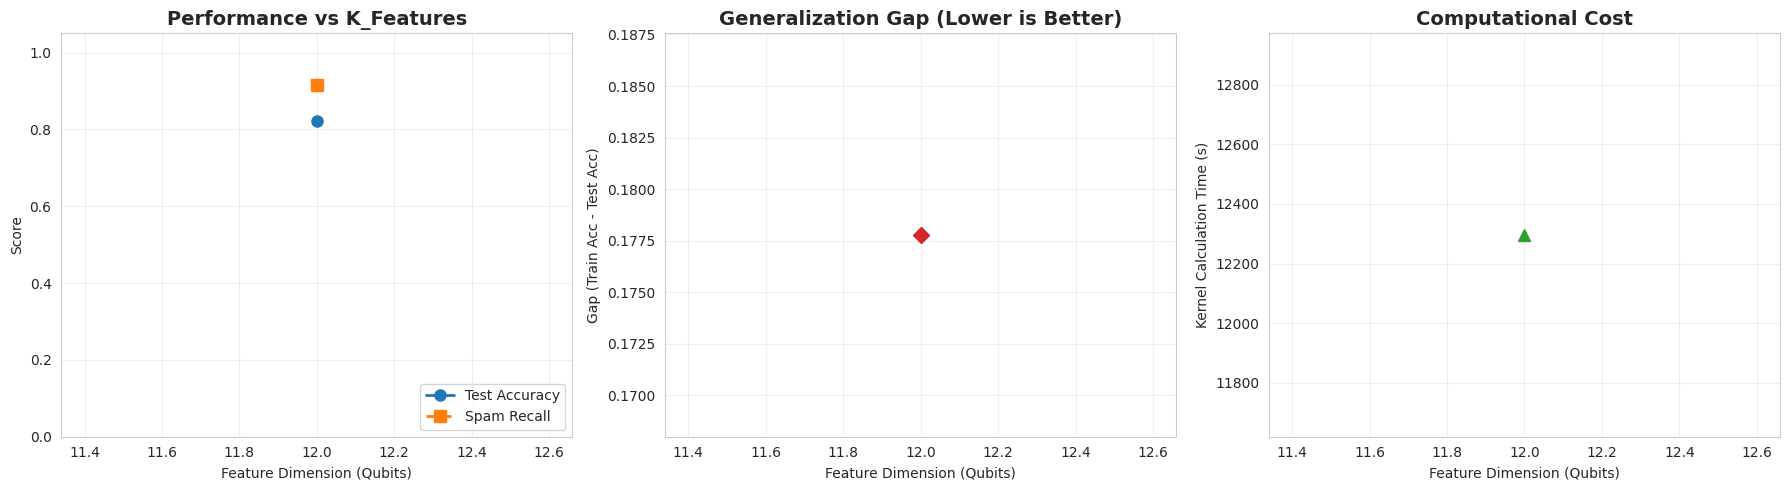


--- Plotting Exp3: Effect of Shots (Measurement) ---


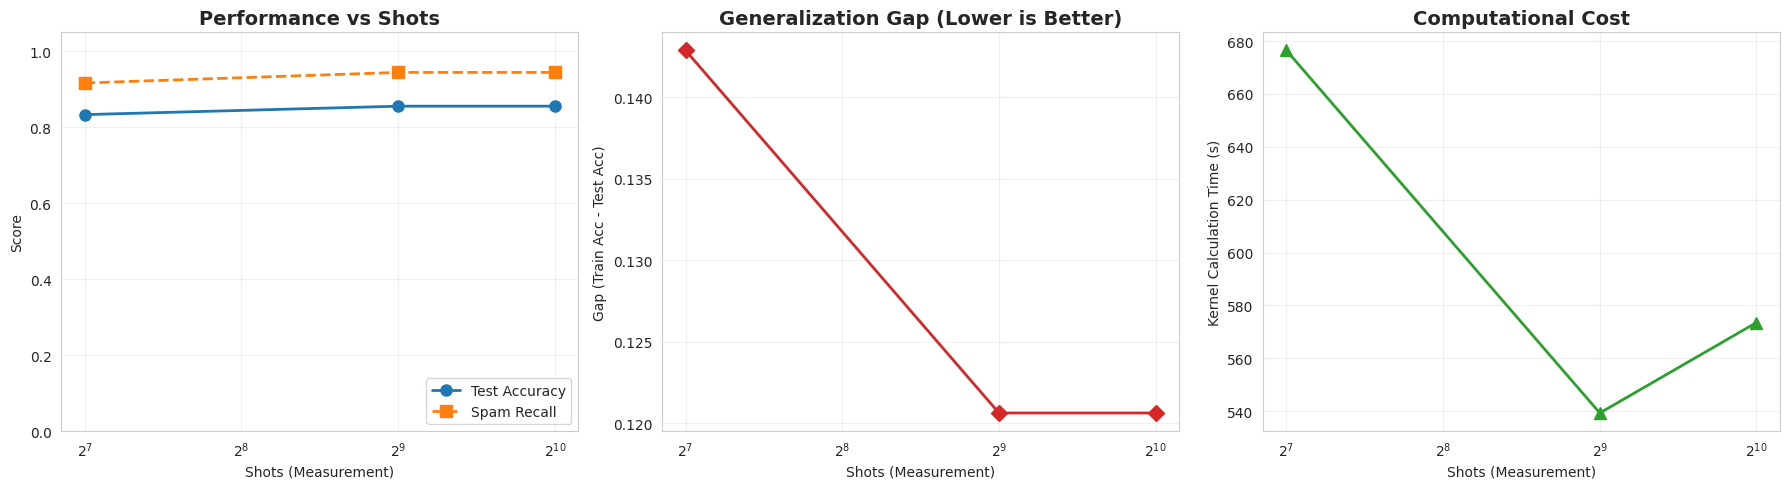


--- Plotting Exp4: Effect of Circuit Depth (Reps) ---


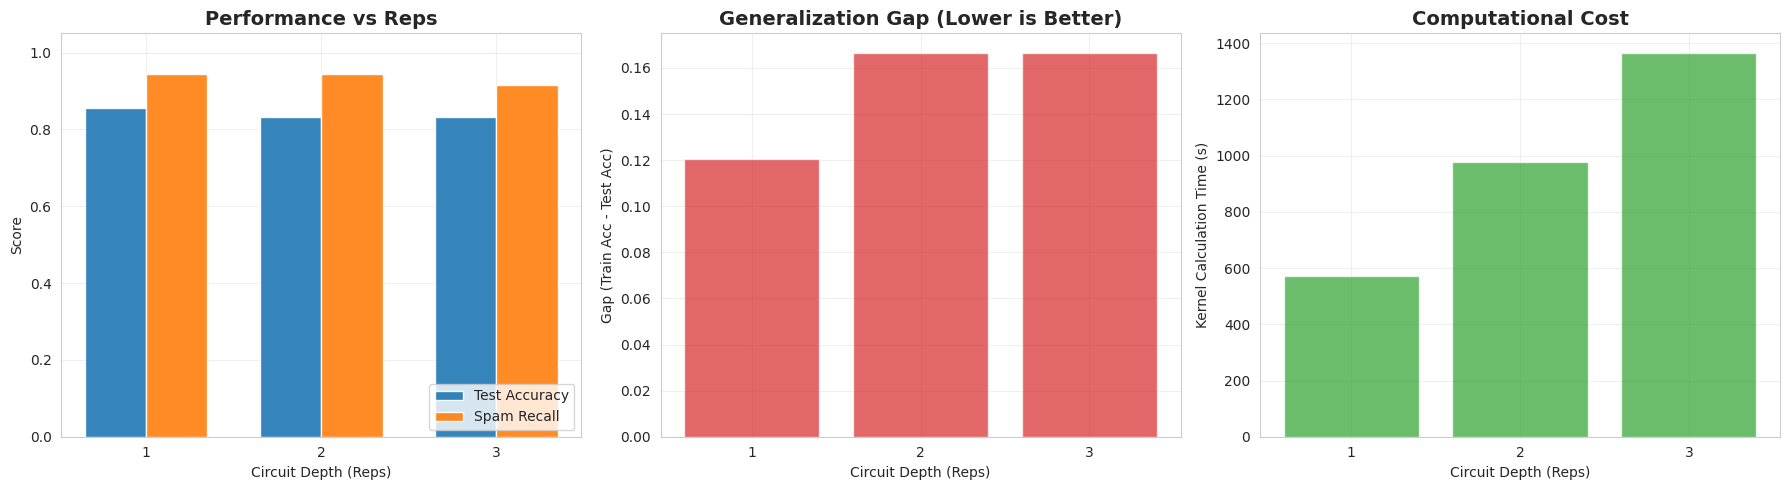


--- Plotting Exp5: Effect of Entanglement Type ---


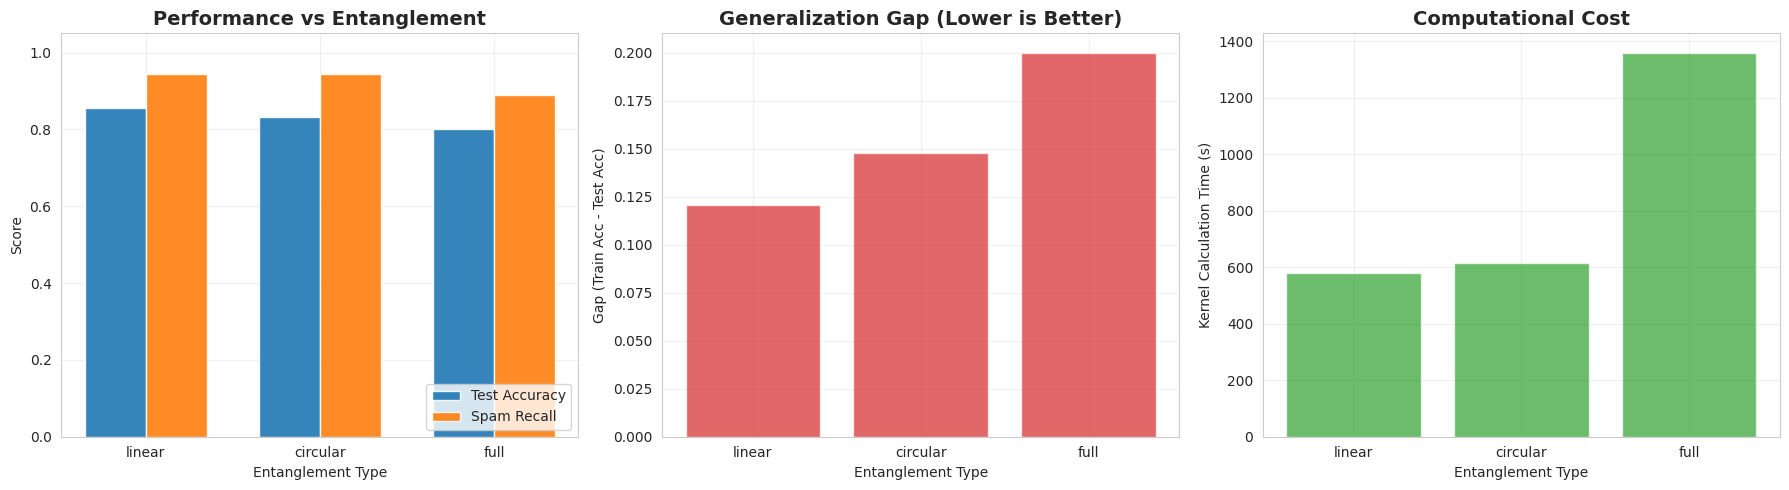


--- Global Performance Overview ---


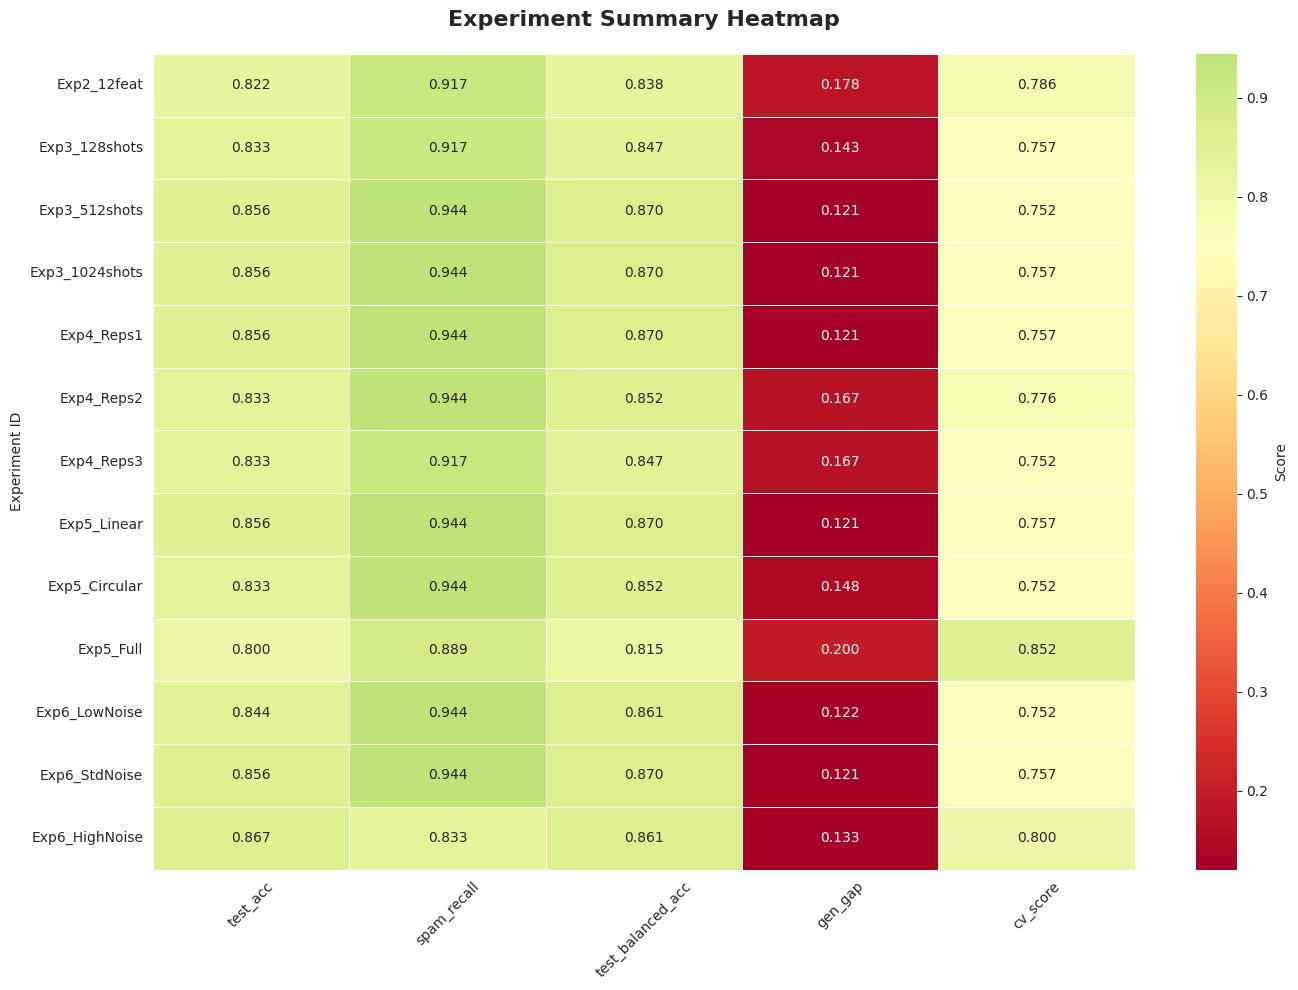

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# ==========================================
# CONFIGURATION & STYLE
# ==========================================
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (18, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['lines.linewidth'] = 2
plt.rcParams['lines.markersize'] = 8

def plot_spambase_consistent_v2(results_data):
    """
    Generates standardized visualizations for Spambase QSVM experiments.
    Accepts either a list of result dicts or a DataFrame.
    """
    
    # Convert to DataFrame if it's a list
    if isinstance(results_data, list):
        df = pd.DataFrame(results_data)
    else:
        df = results_data.copy()

    # Map Experiment IDs to the parameter being varied
    # Based on your notebook: 
    # Exp1 = Sample Size
    # Exp2 = Dimensionality (Features)
    # Exp3 = Shot Noise
    # Exp4 = Reps (Circuit Depth)
    # Exp5 = Entanglement
    
    exp_map = {
        'Exp1': {'param': 'samples',      'xlabel': 'Training Samples',       'log_x': False, 'type': 'line'},
        'Exp2': {'param': 'k_features',   'xlabel': 'Feature Dimension (Qubits)', 'log_x': False, 'type': 'line'},
        'Exp3': {'param': 'shots',        'xlabel': 'Shots (Measurement)',    'log_x': True,  'type': 'line'},
        'Exp4': {'param': 'reps',         'xlabel': 'Circuit Depth (Reps)',   'log_x': False, 'type': 'bar'},
        'Exp5': {'param': 'entanglement', 'xlabel': 'Entanglement Type',      'log_x': False, 'type': 'bar'}
    }

    # Iterate through each defined experiment group
    for group_key, config in exp_map.items():
        # Filter data for this experiment group (matching ID string)
        subset = df[df['experiment_id'].astype(str).str.contains(group_key)].copy()
        
        if subset.empty:
            print(f"Skipping {group_key}: No data found.")
            continue
            
        param = config['param']
        
        # Ensure correct data types for plotting
        if param == 'samples' or param == 'k_features' or param == 'shots' or param == 'reps':
            subset[param] = pd.to_numeric(subset[param])
            
        # Sort by parameter to ensure line plots are ordered correctly
        if config['type'] == 'line':
            subset = subset.sort_values(by=param)
            
        print(f"\n--- Plotting {group_key}: Effect of {config['xlabel']} ---")
        
        fig, axes = plt.subplots(1, 3)
        
        # -------------------------------------------------------
        # SUBPLOT 1: PERFORMANCE (Accuracy vs Recall)
        # -------------------------------------------------------
        if config['type'] == 'bar':
            x_pos = np.arange(len(subset))
            width = 0.35
            # Plot bars
            axes[0].bar(x_pos - width/2, subset['test_acc'], width, label='Test Accuracy', color='#1f77b4', alpha=0.9)
            axes[0].bar(x_pos + width/2, subset['spam_recall'], width, label='Spam Recall', color='#ff7f0e', alpha=0.9)
            axes[0].set_xticks(x_pos)
            axes[0].set_xticklabels(subset[param])
        else:
            # Plot lines
            axes[0].plot(subset[param], subset['test_acc'], 'o-', label='Test Accuracy', color='#1f77b4')
            axes[0].plot(subset[param], subset['spam_recall'], 's--', label='Spam Recall', color='#ff7f0e')
            if config['log_x']: axes[0].set_xscale('log', base=2)

        axes[0].set_xlabel(config['xlabel'])
        axes[0].set_ylabel('Score')
        axes[0].set_title(f'Performance vs {config["param"].title()}')
        axes[0].set_ylim(0, 1.05)
        axes[0].legend(loc='lower right')
        axes[0].grid(True, alpha=0.3)

        # -------------------------------------------------------
        # SUBPLOT 2: GENERALIZATION GAP (Overfitting)
        # -------------------------------------------------------
        if config['type'] == 'bar':
            axes[1].bar(range(len(subset)), subset['gen_gap'], color='#d62728', alpha=0.7)
            axes[1].set_xticks(range(len(subset)))
            axes[1].set_xticklabels(subset[param])
        else:
            axes[1].plot(subset[param], subset['gen_gap'], 'D-', color='#d62728')
            if config['log_x']: axes[1].set_xscale('log', base=2)
            
        axes[1].set_xlabel(config['xlabel'])
        axes[1].set_ylabel('Gap (Train Acc - Test Acc)')
        axes[1].set_title('Generalization Gap (Lower is Better)')
        axes[1].grid(True, alpha=0.3)

        # -------------------------------------------------------
        # SUBPLOT 3: COMPUTATIONAL COST (Time)
        # -------------------------------------------------------
        if config['type'] == 'bar':
            axes[2].bar(range(len(subset)), subset['kernel_time'], color='#2ca02c', alpha=0.7)
            axes[2].set_xticks(range(len(subset)))
            axes[2].set_xticklabels(subset[param])
        else:
            axes[2].plot(subset[param], subset['kernel_time'], '^-', color='#2ca02c')
            if config['log_x']: axes[2].set_xscale('log', base=2)

        axes[2].set_xlabel(config['xlabel'])
        axes[2].set_ylabel('Kernel Calculation Time (s)')
        axes[2].set_title('Computational Cost')
        axes[2].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()

    # -------------------------------------------------------
    # SUMMARY HEATMAP
    # -------------------------------------------------------
    print("\n--- Global Performance Overview ---")
    plt.figure(figsize=(14, 10))
    
    # Metrics to display in heatmap
    # Check if columns exist before selecting
    avail_metrics = [m for m in ['test_acc', 'spam_recall', 'test_balanced_acc', 'gen_gap', 'cv_score'] if m in df.columns]
    
    # Prepare data
    heatmap_data = df.set_index('experiment_id')[avail_metrics]
    
    # Plot
    sns.heatmap(heatmap_data, annot=True, fmt='.3f', cmap='RdYlGn', 
                center=0.75, linewidths=.5, cbar_kws={'label': 'Score'})
    
    plt.title('Experiment Summary Heatmap', fontsize=16, pad=20)
    plt.ylabel('Experiment ID')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# ==========================================
# EXECUTION
# ==========================================
# Note: In your notebook, the results are stored in the list 'all_results'
# If 'all_results' is populated, this will work directly.

try:
    if 'all_results' in locals() and len(all_results) > 0:
        print("Using in-memory 'all_results' list...")
        plot_spambase_consistent_v2(all_results)
    elif 'results_df' in locals():
        print("Using in-memory 'results_df' dataframe...")
        plot_spambase_consistent_v2(results_df)
    else:
        # Fallback: Try to read CSV if available
        print("Attempting to read from CSV...")
        df_temp = pd.read_csv('qsvm_selectkbest_all_experiments.csv')
        plot_spambase_consistent_v2(df_temp)
        
except Exception as e:
    print(f"Could not generate plots: {e}")
    print("Ensure 'all_results' list is populated or 'qsvm_selectkbest_all_experiments.csv' exists.")
